# Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
pd.set_option("display.max_columns", None)
 
metrics = pd.read_parquet("../data/raw/train/battery_metrics.parquet")
eol = pd.read_csv("../data/raw/train/eol_times.csv")
devices = pd.read_csv("../data/raw/train/devices.csv")

metrics = metrics.rename(columns={"end_time": "reading_time"})
eol = eol.rename(columns={"end_time": "failure_time"})
devices = devices.rename(columns={"start_time": "deploy_start", "end_time": "window_end"})
 
metrics["reading_time"] = pd.to_datetime(metrics["reading_time"])
eol["failure_time"] = pd.to_datetime(eol["failure_time"]).dt.tz_localize("UTC")
devices["deploy_start"] = pd.to_datetime(devices["deploy_start"])
devices["window_end"] = pd.to_datetime(devices["window_end"], format='ISO8601')
 
ID_COL = "device_id"
TIME_COL = "reading_time"
VOLTAGE_COL = "voltage"
TEMP_COL = "temperature"
BUILDING_COL = "building_id"
ROOM_COL = "room_id"

 
print("metrics:", metrics.shape, metrics[ID_COL].nunique(), "unique devices")
print("eol:", eol.shape, eol[ID_COL].nunique(), "unique devices")
print("devices:", devices.shape, devices[ID_COL].nunique(), "unique devices")

metrics: (8520098, 4) 461 unique devices
eol: (461, 2) 461 unique devices
devices: (461, 6) 461 unique devices


In [21]:
# number of unique buildings 
unique_buildings = devices[BUILDING_COL].nunique()
print("Number of unique buildings:", unique_buildings)
# table of unique buildings with number of rooms and devices in each building
building_summary = devices.groupby(BUILDING_COL).agg(
    num_rooms=('ROOM_COL', 'nunique'),
    num_devices=('DEVICE_COL', 'size')
)
print("Building Summary:")
print(building_summary)

Number of unique buildings: 24


KeyError: "Column(s) ['DEVICE_COL', 'ROOM_COL'] do not exist"

## Build the survival table
 duration = (failure_time if observed, else window_end) - deploy_start
event = 1 if failure_time is not null, else 0 (censored)

In [7]:
surv = eol.merge(
    devices[[ID_COL, "deploy_start", "window_end", BUILDING_COL, "room_id"]],
    on=ID_COL, how="left"
)
 
surv["event"] = surv["failure_time"].notna().astype(int)
surv["end_of_observation"] = surv["failure_time"].fillna(surv["window_end"])
surv["duration_days"] = (surv["end_of_observation"] - surv["deploy_start"]).dt.total_seconds() / 86400
 
print(surv[["device_id", "deploy_start", "failure_time", "window_end", "event", "duration_days"]].head(10))
print(f"\nAny negative durations? {(surv['duration_days'] < 0).sum()}")
print(f"Any missing deploy_start? {surv['deploy_start'].isna().sum()}")

        device_id              deploy_start              failure_time  \
0  d_f44ef99c6628 2023-07-11 11:18:00+00:00                       NaT   
1  d_57e99ff00802 2023-07-11 11:18:00+00:00 2026-02-02 00:00:00+00:00   
2  d_e1772c236402 2023-07-11 11:18:00+00:00                       NaT   
3  d_3703f0819960 2023-07-11 11:18:00+00:00 2025-09-25 00:00:00+00:00   
4  d_2fb7a37dadcd 2023-01-11 17:16:00+00:00                       NaT   
5  d_20b5bd087fd4 2023-03-02 10:30:00+00:00                       NaT   
6  d_dd190a4f9355 2023-03-02 10:30:00+00:00                       NaT   
7  d_2e144a557e02 2023-03-02 10:30:00+00:00                       NaT   
8  d_063c79be3016 2023-03-02 10:30:00+00:00                       NaT   
9  d_b0638b76cb66 2023-03-02 10:30:00+00:00                       NaT   

                        window_end  event  duration_days  
0 2026-08-01 08:56:35.604152+00:00      0    1116.901801  
1 2026-08-01 08:56:35.604152+00:00      1     936.529167  
2 2026-08-01 08:56:

## Q1 — How many sensors, readings per sensor (min/median/max)? Any with too little history?

Unique sensors in battery_metrics: 461
count      461.000000
mean     18481.774403
std       4971.831867
min       7213.000000
25%      14361.000000
50%      18389.000000
75%      21506.000000
max      32093.000000
dtype: float64

Sensors with the fewest readings:
device_id
d_eb7b60348254     7213
d_12deecea69dd     7517
d_eb8be752b2ff     7539
d_98c67d44ad4d     7544
d_4b58677ce660     7587
d_8753828dd859     7587
d_360efda95d1e     7587
d_0d8e1768cb3a     7621
d_be0fde6cb60d     7690
d_3b8706965be3     7730
d_bd045b2e32a2     7996
d_9c81be30f5ac     8347
d_e48beb704ed4     9260
d_7bd1921d0e3c     9995
d_153b5d46b36b    10249
d_dc8f05c852c6    10284
d_a12d4c724c23    10289
d_a95d5d10df5a    10293
d_a98a55fd1547    10367
d_97f334f0b4f5    10509
dtype: int64

Devices in eol_times with NO rows in battery_metrics: 0


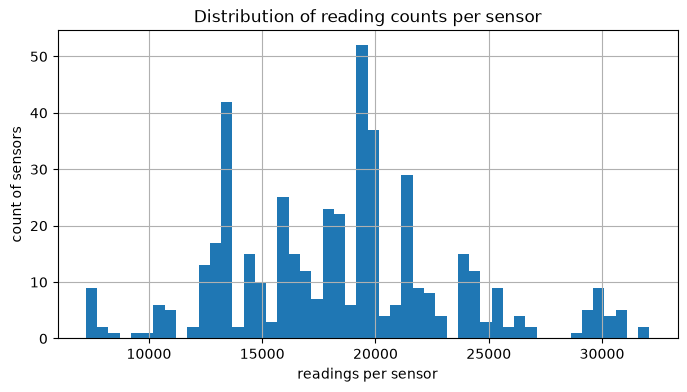

In [8]:
reads_per_sensor = metrics.groupby(ID_COL, observed=True).size()
 
print(f"Unique sensors in battery_metrics: {metrics[ID_COL].nunique()}")
print(reads_per_sensor.describe())
 
low_history = reads_per_sensor.sort_values().head(20)
print("\nSensors with the fewest readings:")
print(low_history)
 
# cross-check: does every device in eol_times/devices actually have metrics rows?
missing_from_metrics = set(eol[ID_COL]) - set(metrics[ID_COL].unique())
print(f"\nDevices in eol_times with NO rows in battery_metrics: {len(missing_from_metrics)}")
 
plt.figure(figsize=(8, 4))
reads_per_sensor.hist(bins=50)
plt.xlabel("readings per sensor")
plt.ylabel("count of sensors")
plt.title("Distribution of reading counts per sensor")
plt.show()

## Q2 — Missing values? Duplicate (device_id, reading_time) rows?

In [9]:
print("Missing values per column (battery_metrics):")
print(metrics.isna().sum())
print(f"\n% rows with any missing: {metrics.isna().any(axis=1).mean():.4%}")
 
dupes = metrics.duplicated(subset=[ID_COL, TIME_COL]).sum()
print(f"\nDuplicate ({ID_COL}, {TIME_COL}) rows: {dupes}")
if dupes > 0:
    dup_mask = metrics.duplicated(subset=[ID_COL, TIME_COL], keep=False)
    print(metrics[dup_mask].sort_values([ID_COL, TIME_COL]).head(10))
 
print("\nMissing values (eol_times, pre-merge):")
print(eol.isna().sum())
print("\nMissing values (devices):")
print(devices.isna().sum())

Missing values per column (battery_metrics):
reading_time    0
voltage         8
temperature     8
device_id       0
dtype: int64

% rows with any missing: 0.0001%

Duplicate (device_id, reading_time) rows: 0

Missing values (eol_times, pre-merge):
device_id         0
failure_time    379
dtype: int64

Missing values (devices):
Unnamed: 0      0
device_id       0
building_id     0
room_id         0
deploy_start    0
window_end      0
dtype: int64


## Q3 — Censoring ratio: % observed deaths vs. % censored?

In [10]:
print(surv["event"].value_counts())
print(surv["event"].value_counts(normalize=True))

event
0    379
1     82
Name: count, dtype: int64
event
0    0.822126
1    0.177874
Name: proportion, dtype: float64


## Q4 — Population Kaplan-Meier curve: sane shape? Median survival time?

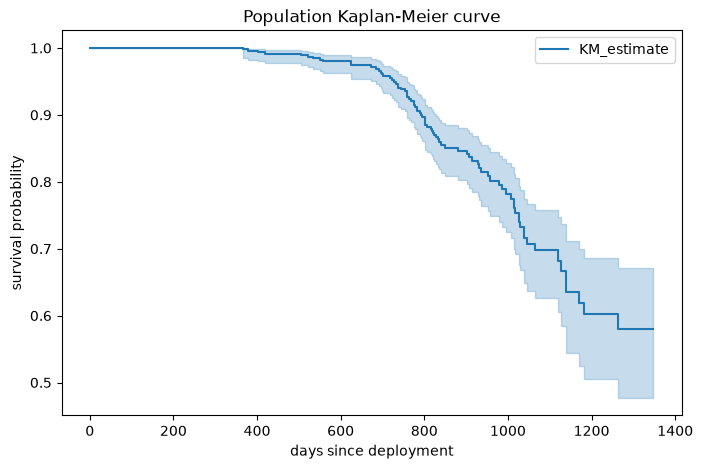

Median survival time (days): inf


In [11]:
from lifelines import KaplanMeierFitter
 
kmf = KaplanMeierFitter()
kmf.fit(surv["duration_days"], event_observed=surv["event"])
 
plt.figure(figsize=(8, 5))
kmf.plot_survival_function()
plt.title("Population Kaplan-Meier curve")
plt.xlabel("days since deployment")
plt.ylabel("survival probability")
plt.show()
 
print(f"Median survival time (days): {kmf.median_survival_time_}")

## Q5 — Do different buildings show visibly different survival curves?

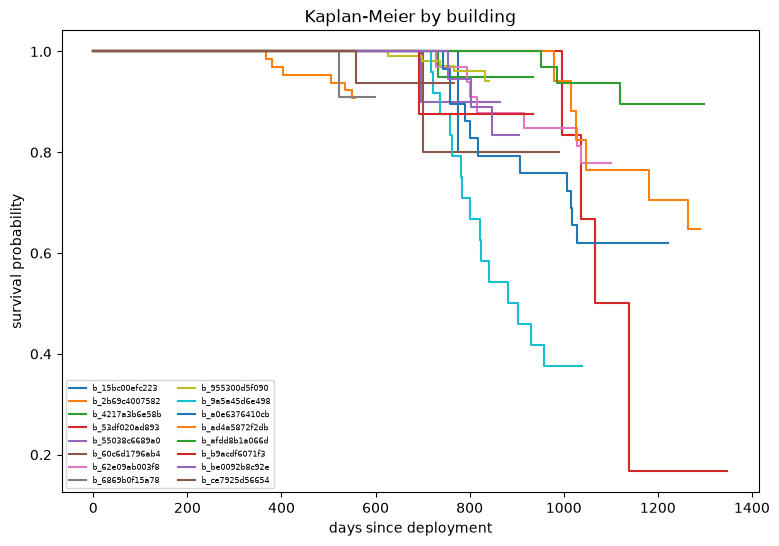

In [12]:
plt.figure(figsize=(9, 6))
ax = plt.subplot(111)
for building, grp in surv.groupby(BUILDING_COL):
    if len(grp) < 5:   # skip buildings with too few devices to plot meaningfully
        continue
    kmf_b = KaplanMeierFitter()
    kmf_b.fit(grp["duration_days"], event_observed=grp["event"], label=str(building))
    kmf_b.plot_survival_function(ax=ax, ci_show=False)
 
plt.title("Kaplan-Meier by building")
plt.xlabel("days since deployment")
plt.ylabel("survival probability")
plt.legend(fontsize=6, ncol=2)
plt.show()

## Q6 — Does voltage visually separate dead vs. still-alive sensors?

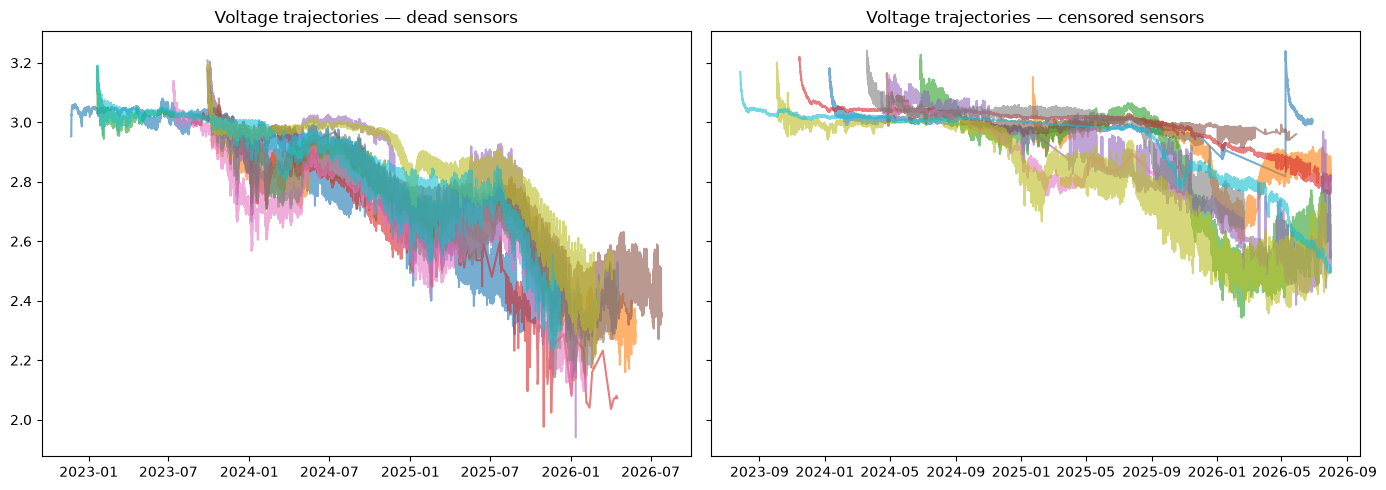

In [14]:
import random 
dead_ids = surv.loc[surv["event"] == 1, ID_COL].tolist()
censored_ids = surv.loc[surv["event"] == 0, ID_COL].tolist()
 
sample_dead = random.sample(dead_ids, min(10, len(dead_ids)))
sample_censored = random.sample(censored_ids, min(10, len(censored_ids)))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
 
for sid in sample_dead:
    d = metrics[metrics[ID_COL] == sid].sort_values(TIME_COL)
    axes[0].plot(d[TIME_COL], d[VOLTAGE_COL], alpha=0.6)
axes[0].set_title("Voltage trajectories — dead sensors")
 
for sid in sample_censored:
    d = metrics[metrics[ID_COL] == sid].sort_values(TIME_COL)
    axes[1].plot(d[TIME_COL], d[VOLTAGE_COL], alpha=0.6)
axes[1].set_title("Voltage trajectories — censored sensors")
 
plt.tight_layout()
plt.show()

## Q7 — Is pooled voltage-temperature correlation misleading (mixed with time-in-life)?

Pooled voltage-temperature correlation: 0.341


C:\Users\welde\AppData\Local\Temp\ipykernel_42856\2160401210.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_sensor_corr = metrics.groupby(ID_COL, observed=True).apply(



Per-sensor correlation distribution:
count    461.000000
mean       0.273773
std        0.217521
min       -0.385288
25%        0.123665
50%        0.263601
75%        0.419266
max        0.889184
dtype: float64


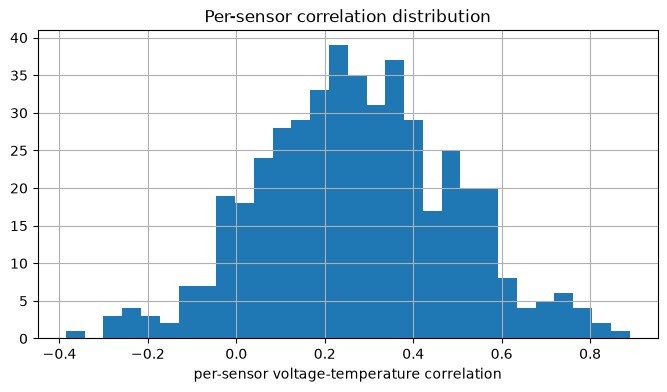

In [15]:
pooled_corr = metrics[[VOLTAGE_COL, TEMP_COL]].corr().iloc[0, 1]
print(f"Pooled voltage-temperature correlation: {pooled_corr:.3f}")
 
per_sensor_corr = metrics.groupby(ID_COL, observed=True).apply(
    lambda d: d[VOLTAGE_COL].corr(d[TEMP_COL]) if len(d) > 5 else np.nan
)
print("\nPer-sensor correlation distribution:")
print(per_sensor_corr.describe())
 
plt.figure(figsize=(8, 4))
per_sensor_corr.hist(bins=30)
plt.xlabel("per-sensor voltage-temperature correlation")
plt.title("Per-sensor correlation distribution")
plt.show()

## Q8 — Do censoring/event duration distributions look sensible?
(censored durations should skew short — they haven't had time to fail yet)

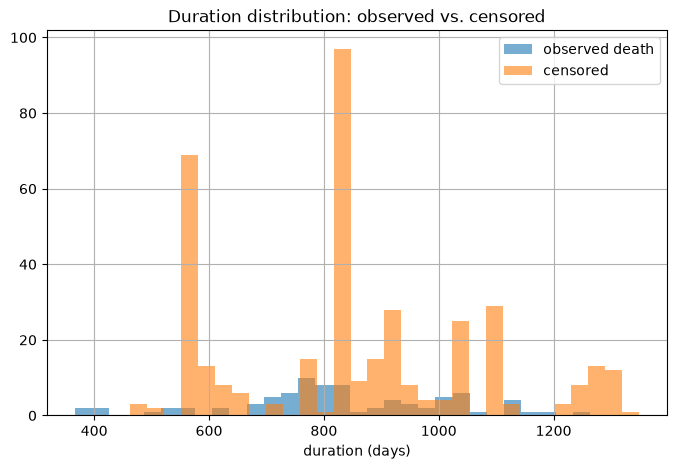

In [16]:
plt.figure(figsize=(8, 5))
surv[surv["event"] == 1]["duration_days"].hist(bins=30, alpha=0.6, label="observed death")
surv[surv["event"] == 0]["duration_days"].hist(bins=30, alpha=0.6, label="censored")
plt.legend()
plt.xlabel("duration (days)")
plt.title("Duration distribution: observed vs. censored")
plt.show()